# Testing the Framework and Code Snippet of the Project
# Quant Predictive MOdel

In [6]:
# First of all the libraries we will need
# Run this once in your terminal
# pip install yfinance pandas scikit-learn xgboost matplotlib seaborn shap
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded successfully")

All libraries loaded successfully


In [9]:
# Phase2 -fetching and EDA
ticker = "AAPL"
df = yf.download(ticker, period="1y")
df = yf.download(ticker, start="2019-01-01", end="2024-01-01")

# Always look at your data first
print(df.shape)
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(1258, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.503723  37.724587  36.627401  36.784142  148158800
2019-01-03  33.768089  34.606413  33.722966  34.193187  365248800
2019-01-04  35.209614  35.278487  34.150430  34.323794  234428400
2019-01-07  35.131237  35.344976  34.649142  35.314102  219111200
2019-01-08  35.800945  36.055057  35.271354  35.518337  164101200
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2023-12-22  191.609467  193.400854  190.985939  193.173208  37149600
2023-12-26  191.065125  191.896484  190.847385  191.619364  28919300
2023-12-27  191.164093  191.510500  189.125276  190.510890  48087700
2023-12-28  191.589676  192.658574  191.183888  


Missing values per column:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


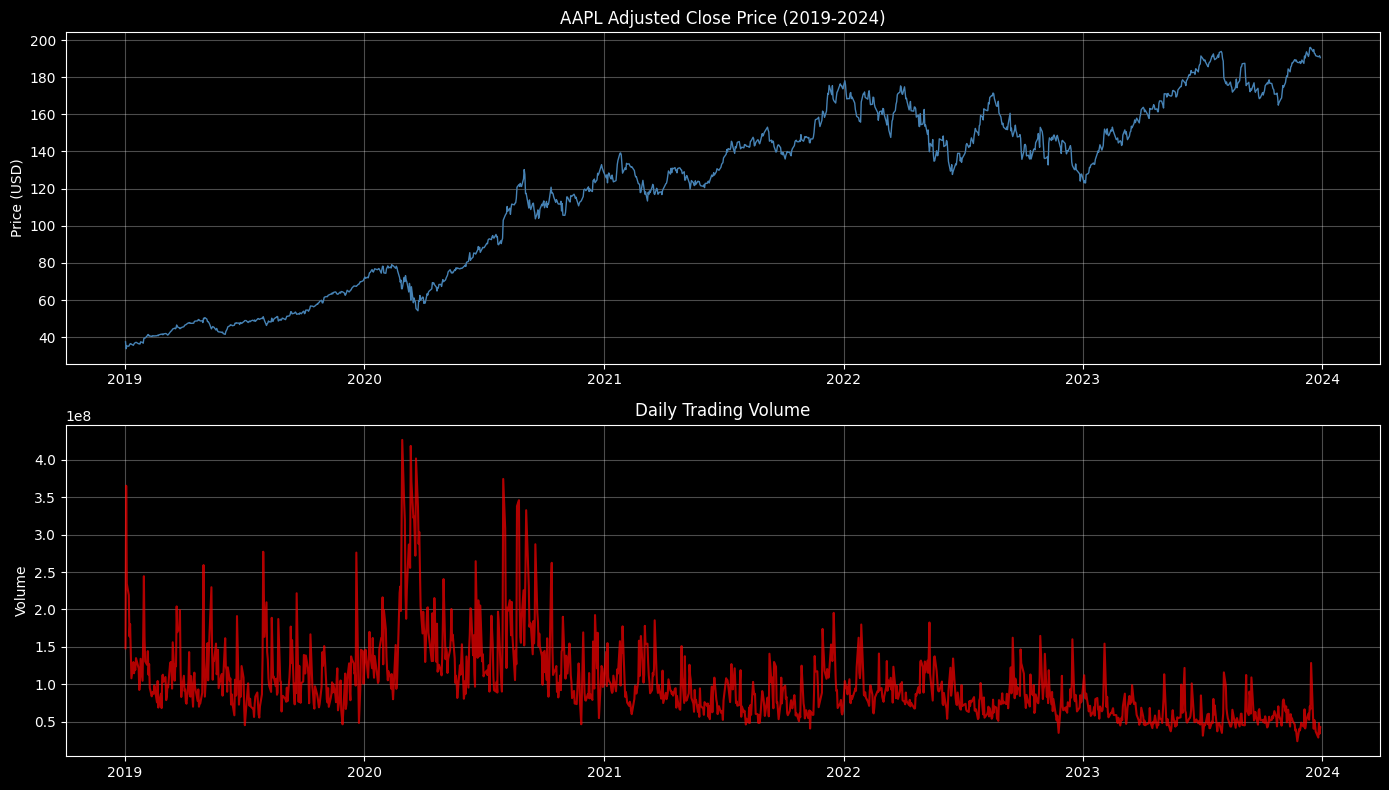

In [25]:
# ---- STEP 2: Check for missing data ----
# Missing values are poison for ML models. We need to know if any exist.
print("\nMissing values per column:")
print(df.isnull().sum())

# ---- STEP 3: Visualize the price history ----
# Your eye can catch patterns that statistics miss.
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price chart
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title(f'{ticker} Adjusted Close Price (2019-2024)')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# Volume chart — trading volume tells you about market activity
axes[1].plot(df.index, df['Volume'], color='red', alpha=0.7)
axes[1].set_title('Daily Trading Volume')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# ---- STEP 4: Create technical indicator features ----
# We work on a copy to preserve our original data.
features = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
features.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# --- Moving Averages ---
# A 10-day SMA smooths out daily noise to show the short-term trend.
# A 50-day SMA shows the medium-term trend.
# When the short MA crosses above the long MA, it's often a bullish signal.
features['SMA_10'] = features['Close'].rolling(window=10).mean()
features['SMA_50'] = features['Close'].rolling(window=50).mean()

# The ratio is more useful than the raw values — it's scale-invariant.
features['SMA_ratio'] = features['SMA_10'] / features['SMA_50']

# --- RSI: Relative Strength Index ---
# RSI measures momentum. Above 70 = overbought, below 30 = oversold.
# This is the most widely used momentum indicator in finance.
def compute_rsi(series, period=14):
    delta = series.diff()                          # Daily price changes
    gain = delta.clip(lower=0)                     # Only keep positive changes
    loss = -delta.clip(upper=0)                    # Only keep negative changes (as positive)
    avg_gain = gain.rolling(window=period).mean()  # Average gain over the period
    avg_loss = loss.rolling(window=period).mean()  # Average loss over the period
    rs = avg_gain / avg_loss                       # Relative strength ratio
    return 100 - (100 / (1 + rs))                  # Normalized to 0-100

features['RSI_14'] = compute_rsi(features['Close'])

# --- Bollinger Bands ---
# Price channel around a moving average. Wide bands = high volatility.
# When price hits the upper band, it may be overbought.
bb_window = 20
features['BB_mid'] = features['Close'].rolling(window=bb_window).mean()
bb_std = features['Close'].rolling(window=bb_window).std()
features['BB_upper'] = features['BB_mid'] + (2 * bb_std)
features['BB_lower'] = features['BB_mid'] - (2 * bb_std)
# The position within the band (0 = at lower, 1 = at upper)
features['BB_position'] = (features['Close'] - features['BB_lower']) / \
                           (features['BB_upper'] - features['BB_lower'])

# --- Volatility ---
# Daily returns and their rolling standard deviation.
features['Daily_return'] = features['Close'].pct_change()          # % change day-over-day
features['Volatility_10'] = features['Daily_return'].rolling(10).std()  # 10-day volatility

# --- Volume signal ---
# Is today's volume above or below the recent average?
# High-volume moves are more "real" than low-volume ones.
features['Volume_ratio'] = features['Volume'] / features['Volume'].rolling(20).mean()

# --- Lag features ---
# Yesterday's return is a feature for predicting today. This is key for time series.
features['Return_lag1'] = features['Daily_return'].shift(1)  # Yesterday's return
features['Return_lag2'] = features['Daily_return'].shift(2)  # Two days ago

print(f"Feature set shape: {features.shape}")
print(features.tail(10))

Feature set shape: (1258, 18)
                  Open        High         Low       Close     Volume  \
Date                                                                    
2023-12-15  195.499069  196.360119  194.974519  195.538666  128538400   
2023-12-18  194.073856  194.608312  192.391338  193.875916   55751900   
2023-12-19  194.143152  194.925022  193.875923  194.915131   40714100   
2023-12-20  194.875522  195.647501  192.826813  192.826813   52242800   
2023-12-21  194.083789  195.053709  191.510515  192.678375   46482500   
2023-12-22  193.173208  193.400854  190.985939  191.609467   37149600   
2023-12-26  191.619364  191.896484  190.847385  191.065125   28919300   
2023-12-27  190.510890  191.510500  189.125276  191.164093   48087700   
2023-12-28  192.143916  192.658574  191.183888  191.589676   34049900   
2023-12-29  191.906370  192.401229  189.758683  190.550461   42672100   

                SMA_10      SMA_50  SMA_ratio     RSI_14      BB_mid  \
Date                 

In [28]:
# ---- STEP 5: Create the target variable ----
# Target = 1 if tomorrow's close is HIGHER than today's, else 0.
# We use .shift(-1) to look at the NEXT day's price.
features['Target'] = (features['Close'].shift(-1) > features['Close']).astype(int)

# Drop rows with NaN values (from rolling windows and shifts)
# Rolling(50) creates 49 NaN rows at the start, for example.
features.dropna(inplace=True)

print(f"\nDataset after cleaning: {features.shape[0]} trading days")
print(f"\nClass distribution (0=down, 1=up):")
print(features['Target'].value_counts(normalize=True).round(3))
# You want a roughly 50/50 split. If it's very imbalanced, you need special techniques.


Dataset after cleaning: 1209 trading days

Class distribution (0=down, 1=up):
Target
1    0.532
0    0.468
Name: proportion, dtype: float64


In [29]:
# ---- STEP 6: Split into features (X) and target (y) ----
feature_cols = ['SMA_ratio', 'RSI_14', 'BB_position', 'Volatility_10',
                'Volume_ratio', 'Return_lag1', 'Return_lag2']

X = features[feature_cols]
y = features['Target']

# ---- CRITICAL: Time-series split (NOT random split!) ----
# For financial data, you must respect time order.
# You CANNOT train on 2022 data and test on 2021 — that's cheating.
# We use the last 20% of time as our test set.
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {len(X_train)} days")
print(f"Test set:     {len(X_test)} days")

# ---- STEP 7: Scale features ----
# Many ML algorithms assume features are on similar scales.
# StandardScaler transforms each feature to mean=0, std=1.
# We fit ONLY on training data, then apply to both — never let test data influence the scaler.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # only transform on test

Training set: 967 days
Test set:     242 days


In [30]:
# ---- STEP 8: Train three models (simplest to most powerful) ----

# Model 1: Logistic Regression — the humble baseline
# It finds a linear boundary between "up" and "down" days.
# If a fancier model can't beat this, something is wrong.
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# Model 2: Random Forest — ensemble of decision trees
# Each tree sees a random subset of data and features.
# The majority vote across 200 trees is very robust to overfitting.
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

# Model 3: XGBoost — the current king of tabular ML
# Builds trees sequentially, each one correcting the errors of the previous.
# 'use_label_encoder=False' and 'eval_metric' suppress warnings.
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               random_state=42, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

In [31]:
# ---- STEP 9: Compare model performance ----
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr_preds,
    "Random Forest":       rf_preds,
    "XGBoost":             xgb_preds
}

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    print(f"\n{'='*40}")
    print(f"{name} — Accuracy: {acc:.3f}")
    print(classification_report(y_test, preds, target_names=['Down', 'Up']))


Logistic Regression — Accuracy: 0.554
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       108
          Up       0.55      1.00      0.71       134

    accuracy                           0.55       242
   macro avg       0.28      0.50      0.36       242
weighted avg       0.31      0.55      0.39       242


Random Forest — Accuracy: 0.529
              precision    recall  f1-score   support

        Down       0.45      0.25      0.32       108
          Up       0.55      0.75      0.64       134

    accuracy                           0.53       242
   macro avg       0.50      0.50      0.48       242
weighted avg       0.51      0.53      0.50       242


XGBoost — Accuracy: 0.525
              precision    recall  f1-score   support

        Down       0.46      0.41      0.43       108
          Up       0.56      0.62      0.59       134

    accuracy                           0.52       242
   macro avg       0.51      

Strategy Sharpe Ratio:    1.116
Buy-and-Hold Sharpe Ratio: 1.809


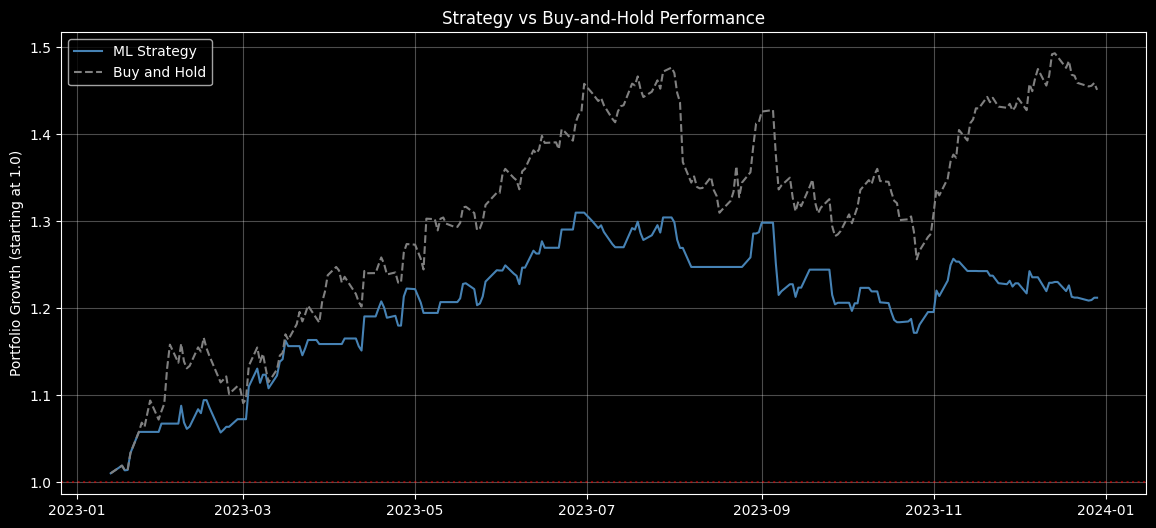

In [32]:
# ---- STEP 10: Backtesting — does the model make money? ----
# Accuracy alone doesn't tell you if the model is profitable.
# A model that's 52% accurate but always wrong on big moves is useless.

# Get XGBoost's probability estimates (not just 0/1 predictions)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]  # Probability of "Up"

# Build a simple backtest: go long when model says "Up" (proba > 0.5)
backtest = pd.DataFrame({
    'Date':         X_test.index,
    'Actual_return': features.loc[X_test.index, 'Daily_return'],
    'Signal':        (xgb_proba > 0.5).astype(int)  # 1 = buy, 0 = stay out
})

# Strategy return = signal * actual return
backtest['Strategy_return'] = backtest['Signal'] * backtest['Actual_return']
# Buy-and-hold benchmark: just hold the stock every day
backtest['Cumulative_buyhold']  = (1 + backtest['Actual_return']).cumprod()
backtest['Cumulative_strategy'] = (1 + backtest['Strategy_return']).cumprod()

# Sharpe Ratio: return per unit of risk (higher is better; >1 is good, >2 is great)
def sharpe_ratio(returns, risk_free_rate=0.05/252):
    excess = returns - risk_free_rate
    return (excess.mean() / excess.std()) * np.sqrt(252)  # Annualized

sr_strategy  = sharpe_ratio(backtest['Strategy_return'])
sr_benchmark = sharpe_ratio(backtest['Actual_return'])

print(f"Strategy Sharpe Ratio:    {sr_strategy:.3f}")
print(f"Buy-and-Hold Sharpe Ratio: {sr_benchmark:.3f}")

# Plot the equity curves
plt.figure(figsize=(14, 6))
plt.plot(backtest['Date'], backtest['Cumulative_strategy'],  label='ML Strategy',   color='steelblue')
plt.plot(backtest['Date'], backtest['Cumulative_buyhold'],   label='Buy and Hold',  color='gray', linestyle='--')
plt.axhline(1, color='red', linestyle=':', alpha=0.5)
plt.title('Strategy vs Buy-and-Hold Performance')
plt.ylabel('Portfolio Growth (starting at 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

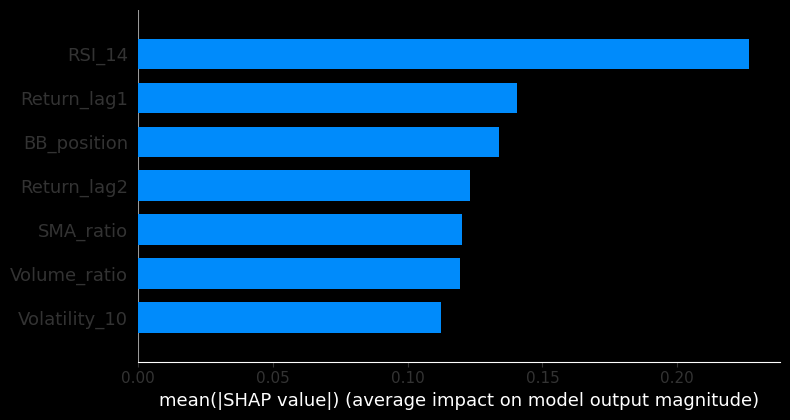

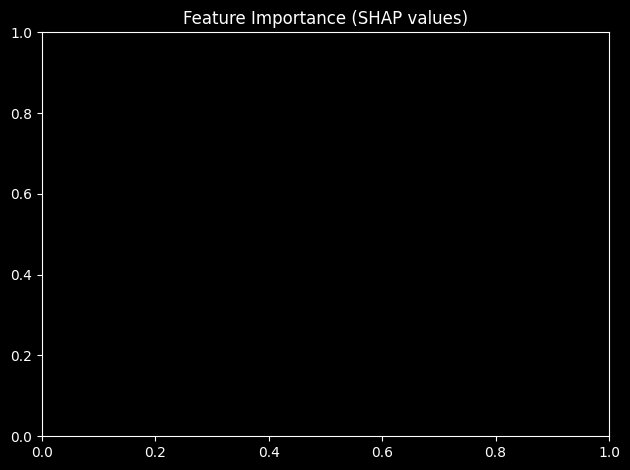

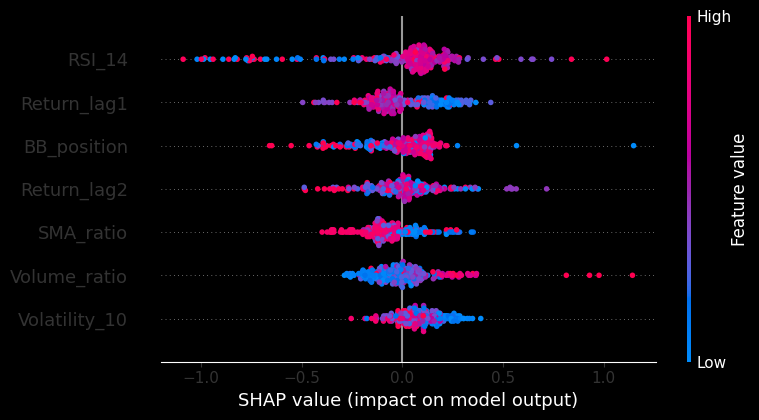

In [33]:
# ---- STEP 11: Explainability with SHAP ----
# SHAP (SHapley Additive exPlanations) tells you HOW MUCH each feature
# contributed to each individual prediction. This is crucial in finance
# because regulators and PMs need to understand WHY a model is trading.

explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test_scaled)

# Summary plot: which features matter most overall?
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar")
plt.title("Feature Importance (SHAP values)")
plt.tight_layout()
plt.show()

# Detailed plot: how does each feature's VALUE affect predictions?
# Red = high feature value, Blue = low feature value
# Right = pushes model toward predicting "Up", Left = toward "Down"
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)